# Time Series Analysis with Python


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
)


air = pd.read_csv(url)
air["Month"] = pd.to_datetime(air["Month"])
air.set_index("Month", inplace=True)
air.columns = ["Passengers"]

print(f"Range of data: {air.index.min()} to {air.index.max()}")
print(f"Frequency monthly: {len(air)} records")
print(air.head())

Range of data: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Frequency monthly: 144 records
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


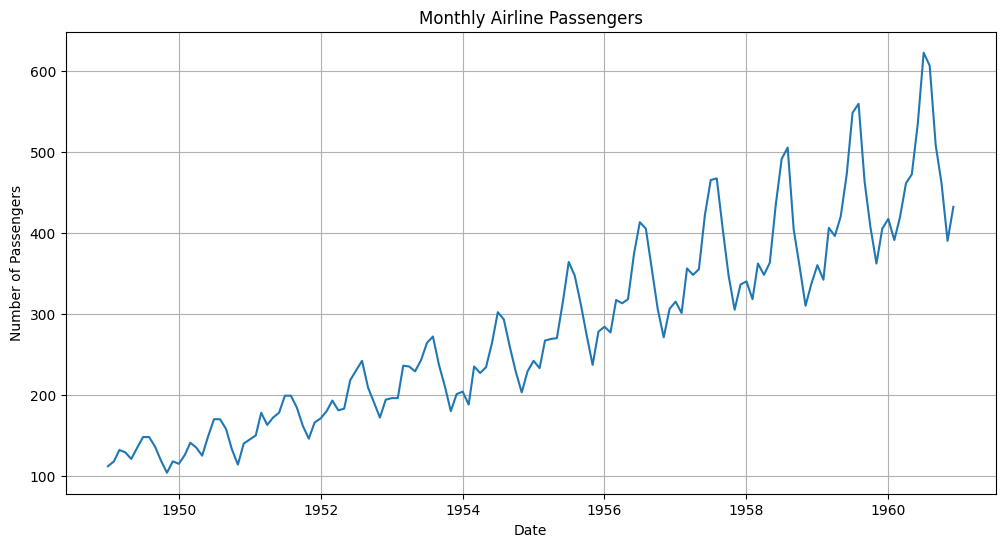

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(air.index, air["Passengers"])
ax.set_title("Monthly Airline Passengers")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Passengers")
ax.grid()
plt.show()

## 2. Key properties of time series


### 2.1 Frequency

The time spacing between observations. Common frequencies include:

- **Hourly** (`H`)
- **Daily** (`D`)
- **Monthly** (`M`)
- **Quarterly** (`Q`)
- **Yearly** (`Y`)


In [13]:
print(f"Inferred frequency: {air.index.inferred_freq}")

air_q = air.resample("QS").sum()

Inferred frequency: MS


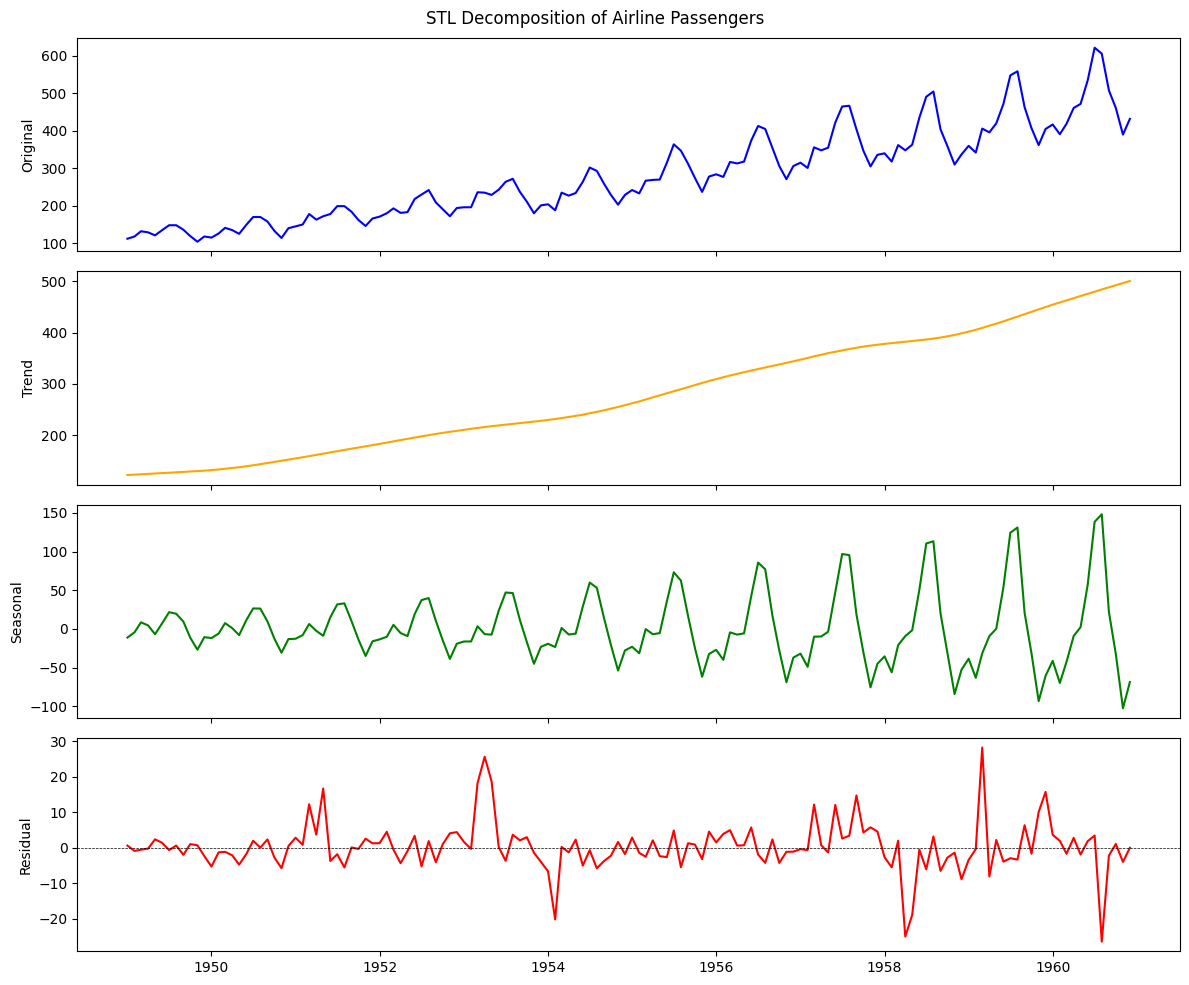

In [14]:
from statsmodels.tsa.seasonal import STL

stl = STL(air["Passengers"], period=12, robust=True)

decomp = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(air.index, air["Passengers"], label="Original", color="blue")
axes[0].set_ylabel("Original")
axes[1].plot(air.index, decomp.trend, label="Trend", color="orange")
axes[1].set_ylabel("Trend")
axes[2].plot(air.index, decomp.seasonal, label="Seasonal", color="green")
axes[2].set_ylabel("Seasonal")
axes[3].plot(air.index, decomp.resid, label="Residual", color="red")
axes[3].set_ylabel("Residual")
axes[3].axhline(0, color="black", linestyle="--", linewidth=0.5)

plt.suptitle("STL Decomposition of Airline Passengers")
plt.tight_layout()
plt.show()


In [17]:
train = air.iloc[:-12]
test = air.iloc[-12:]

In [25]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw = ExponentialSmoothing(
    train["Passengers"], trend="add", seasonal="mul", seasonal_periods=12
).fit()

hw_forecast = hw.forecast(steps=12)

mae_hw = np.mean(np.abs(hw_forecast - test["Passengers"]))
print(f"Holt-Winters MAE: {mae_hw:.2f}")

Holt-Winters MAE: 10.30


/home/aligator/projects/agh/de/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


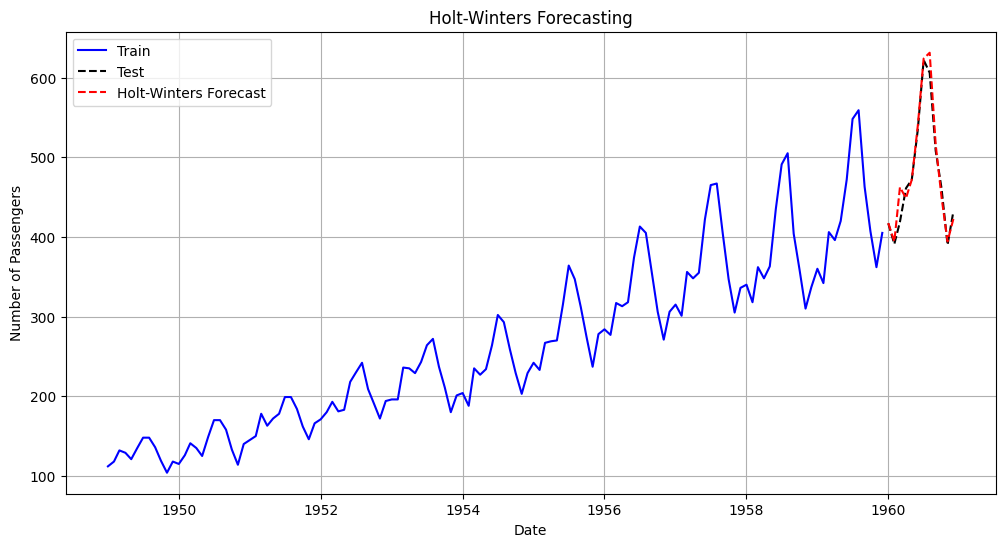

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train.index, train["Passengers"], label="Train", color="blue")
ax.plot(test.index, test["Passengers"], "k--", label="Test")
ax.plot(hw_forecast.index, hw_forecast, "r--", label="Holt-Winters Forecast")
ax.set_title("Holt-Winters Forecasting")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Passengers")
ax.legend()
ax.grid()
plt.show()

In [32]:
url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
)

air = pd.read_csv(url)
air["Month"] = pd.to_datetime(air["Month"])

air.columns = ["ds", "y"]
air["unique_id"] = "AirPassengers"
air = air[["unique_id", "ds", "y"]]

h = 24
train = air.iloc[:-h].copy()
test = air.iloc[-h:].copy()
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (120, 3), Test shape: (24, 3)


In [34]:
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP, NBEATS, NHITS, TSMixer

models = [
    NBEATS(input_size=24, h=h, max_steps=800),
    NHITS(input_size=24, h=h, max_steps=800),
    MLP(input_size=24, h=h, max_steps=800),
    TSMixer(
        input_size=24,
        h=h,
        max_steps=800,
        n_series=1,
        n_block=2,
        ff_dim=64,
        dropout=0.9,
        revin=True,
    ),
]

nf = NeuralForecast(models=models, freq="MS")
nf.fit(train)

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
2.4 K     Non-trainable params
2.5 M     Total params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/aligator/projects/agh/de/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=800` reached.


In [35]:
print("\nForecasting with NeuralForecast models:")
print(nf.predict(test).head())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Forecasting with NeuralForecast models:


/home/aligator/projects/agh/de/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

       unique_id         ds      NBEATS       NHITS         MLP     TSMixer
0  AirPassengers 1961-01-01  447.423584  439.742004  439.591492  449.120605
1  AirPassengers 1961-02-01  416.827881  414.791351  410.727142  443.353607
2  AirPassengers 1961-03-01  466.299835  463.007324  463.589722  456.197083
3  AirPassengers 1961-04-01  443.955627  451.218079  483.528748  482.070129
4  AirPassengers 1961-05-01  463.651276  461.320374  506.443878  528.213806


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/aligator/projects/agh/de/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

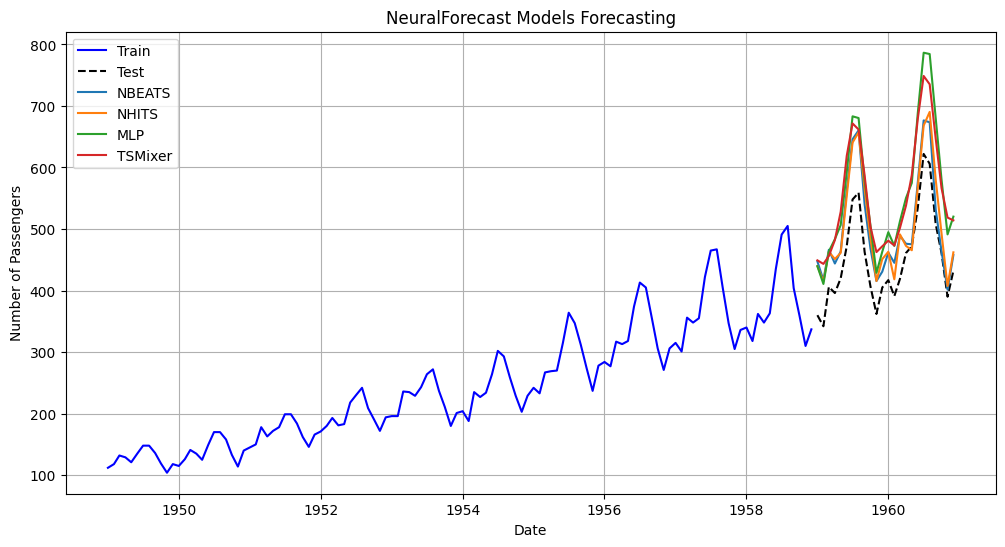

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train["ds"], train["y"], label="Train", color="blue")
ax.plot(test["ds"], test["y"], "k--", label="Test")
for model in models:
    forecast = nf.predict(test, verbose=False)[model.__class__.__name__]
    ax.plot(test["ds"], forecast, label=model.__class__.__name__)
ax.set_title("NeuralForecast Models Forecasting")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Passengers")
ax.legend()
ax.grid()
plt.show()